In [1]:
!pip install transformers datasets scikit-learn --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 4.3 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
bigframes 1.42.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.9.0.13 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cudnn-cu12==9.1.0.70; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cudnn-cu12 9.3.0.75 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cufft-cu12==11.2.1.3; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cufft-cu12 11.4.0.6 which is incompatible.
torch 2.6.0+

In [3]:
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

file_path = "/kaggle/input/arat5-dataset/merged_file_unique_by_question_new.csv"
df = pd.read_csv(file_path)
df = df.rename(columns={"arabic_question": "input_text", "sql_query": "target_text"})

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df)
})

model_ckpt = "UBC-NLP/araT5-base"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt)

max_input_length = 128
max_target_length = 128

def preprocess_function(examples):
    inputs = examples["input_text"]
    targets = examples["target_text"]

    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True, padding="max_length")

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=max_target_length, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


encoded_dataset = dataset.map(preprocess_function, batched=True)

training_args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/arat5_sql_model2",
    per_device_train_batch_size=2,  
    num_train_epochs=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_total_limit=2,
    save_steps=22700,
    eval_strategy="epoch",
    logging_dir="/kaggle/working/logs2",
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

model.save_pretrained("/kaggle/working/arat5_sql_model2")
tokenizer.save_pretrained("/kaggle/working/arat5_sql_model2")


Map:   0%|          | 0/45628 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/11407 [00:00<?, ? examples/s]

/tmp/ipykernel_35/1603865026.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,0.039900,0.015182
2,0.013400,0.004542
3,0.006000,0.002167
4,0.004400,0.001387
5,0.002800,0.001250


('/kaggle/working/arat5_sql_model2/tokenizer_config.json',
 '/kaggle/working/arat5_sql_model2/special_tokens_map.json',
 '/kaggle/working/arat5_sql_model2/spiece.model',
 '/kaggle/working/arat5_sql_model2/added_tokens.json',
 '/kaggle/working/arat5_sql_model2/tokenizer.json')

In [4]:
!zip -r /kaggle/working/arat5_sql_model2/checkpoint-114070 /kaggle/working/arat5_sql_model2/checkpoint-114070


  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/ (stored 0%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/spiece.model

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 54%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/generation_config.json (deflated 29%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/config.json (deflated 47%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/optimizer.pt (deflated 7%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/tokenizer.json (deflated 77%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/tokenizer_config.json (deflated 68%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/model.safetensors (deflated 7%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/rng_state.pth (deflated 25%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/scheduler.pt (deflated 56%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/training_args.bin (deflated 52%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/trainer_state.json (deflated 78%)
  adding: kaggle/working/arat5_sql_model2/checkpoint-114070/special_t

In [5]:
import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

checkpoint_path = "/kaggle/working/arat5_sql_model2/checkpoint-114070"
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint_path)
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)

original_data_path = "/kaggle/input/arat5-dataset/merged_file_unique_by_question_new.csv"
df = pd.read_csv(original_data_path)
df = df.rename(columns={"arabic_question": "input_text", "sql_query": "target_text"})

from sklearn.model_selection import train_test_split
_, val_df = train_test_split(df, test_size=0.2, random_state=42)

def predict_sql(question):
    inputs = tokenizer(question, return_tensors="pt", truncation=True, padding=True, max_length=64)
    outputs = model.generate(**inputs, max_length=64)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

questions = val_df["input_text"].astype(str).tolist()
true_sqls = val_df["target_text"].astype(str).tolist()

predicted_sqls = []
for q in tqdm(questions, desc="جاري التنبؤ"):
    predicted_sqls.append(predict_sql(q))

preds_norm = [p.lower().strip() for p in predicted_sqls]
trues_norm = [t.lower().strip() for t in true_sqls]

y_true = [1] * len(trues_norm)
y_pred = [1 if p == t else 0 for p, t in zip(preds_norm, trues_norm)]

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n📊 نتائج التقييم على Validation:")
print(f"   - Accuracy : {acc * 100:.f}%")
print(f"   - Precision: {prec * 100:.2f}%")
print(f"   - Recall   : {rec * 100:.2f}%")
print(f"   - F1 Score : {f1 * 100:.2f}%")


جاري التنبؤ: 100%|██████████| 11407/11407 [3:44:27<00:00,  1.18s/it] 


📊 نتائج التقييم على Validation:
   - Accuracy : 96.58%
   - Precision: 100.00%
   - Recall   : 96.58%
   - F1 Score : 98.26%


##  1. Training vs. Validation Loss Plot

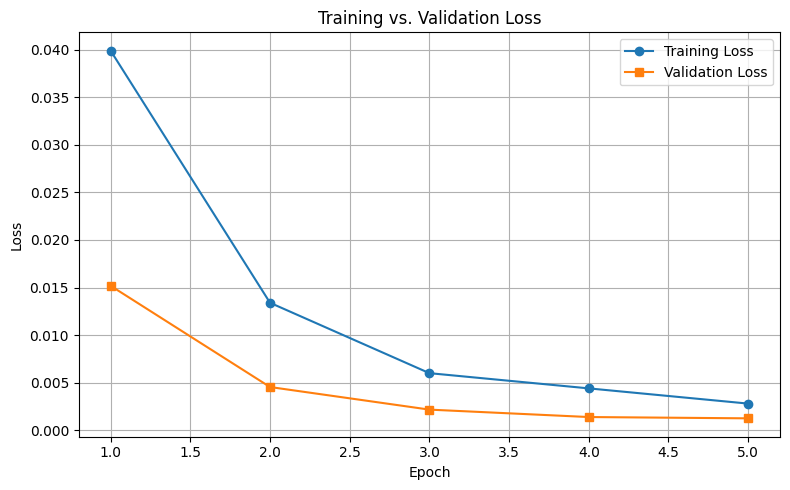

In [2]:
import matplotlib.pyplot as plt


# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, training_loss, label='Training Loss', marker='o')
plt.plot(epochs, validation_loss, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##  2. Validation Metrics Bar Chart

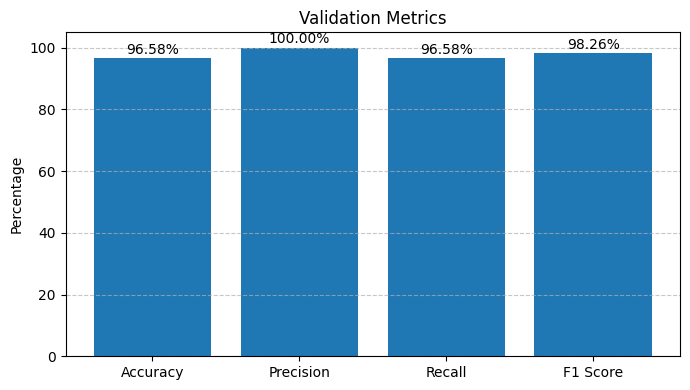

In [4]:
import matplotlib.pyplot as plt


# Plotting
plt.figure(figsize=(7, 4))
bars = plt.bar(metrics, values)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom')

plt.ylim(0, 105)
plt.title('Validation Metrics')
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## # 📌 4. Learning Rate vs. Epoch (From Hugging Face trainer_state.json)


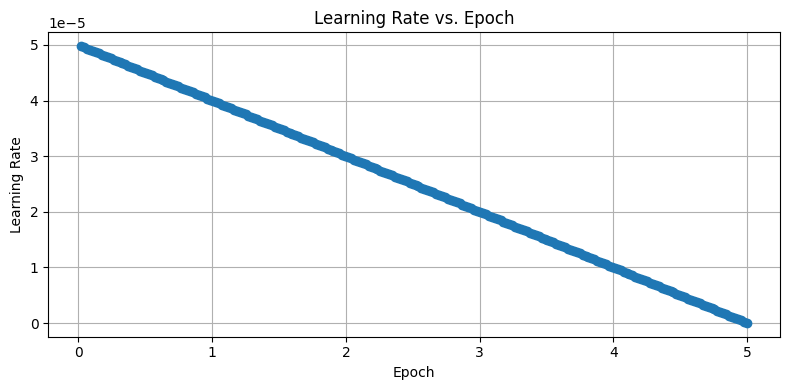

In [5]:

import matplotlib.pyplot as plt
import json

# Load trainer_state.json from checkpoint folder
with open('/kaggle/input/modelresult/checkpoint-114070/trainer_state.json') as f:
    data = json.load(f)

# Extract learning rate per epoch
log_history = data.get('log_history', [])
epochs = []
learning_rates = []

for entry in log_history:
    if 'learning_rate' in entry and 'epoch' in entry:
        epochs.append(entry['epoch'])
        learning_rates.append(entry['learning_rate'])

# Plot learning rate schedule
plt.figure(figsize=(8, 4))
plt.plot(epochs, learning_rates, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate vs. Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()
